# Data processing

- Z-score scaler for load and weather parameters
- both sine & cosine function for time feature transformation
- IQR for data cleaning
- 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
import joblib
import json

In [45]:
# 1. JSON Parser specifically for the API
# ==========================================
def parse_simpl_energy_json(json_payload):
    """Parses the specific JSON structure into a Pandas DataFrame."""
    times = json_payload['history']['times']
    data_dict = json_payload['history']['data']
    
    # Create DataFrame
    df = pd.DataFrame(data_dict)
    
    # Convert times to datetime and set as index
    df['times'] = pd.to_datetime(times)
    df.set_index('times', inplace=True)
    
    original_len = len(df)
    print(f"Original Data Length (raw rows): {original_len}")
    
    # Enforce 15-minute frequency to expose any completely missing rows
    df = df.asfreq('15min')
    print(f"Length after enforcing 15-minute frequency: {len(df)}")
    
    return df

# ==========================================
# 2. Refined Data Processor
# ==========================================
class DataProcessor:
    def __init__(self):
        self.scaler = StandardScaler()
        self.iqr_bounds = {}

        # 1. Explicitly list the exact features you want to KEEP
        self.selected_features = ['shortwave_radiation', 'temperature_2m'] 
        self.target = ['y']

        # Add the new engineered feature explicitly
        self.engineered_features = ['y_hist_avg']
        
        # 2. Dynamically build the processing lists
        self.scale_cols = self.selected_features + self.target + self.engineered_features
        self.outlier_cols = self.selected_features.copy()
        
        # 3. Define the final output columns 
        self.time_features = ['hour_sin', 'hour_cos', 'dayofweek_sin',  'dayofyear_sin', 'dayofyear_cos', 'dayofweek_cos']
        self.final_columns = self.scale_cols + self.time_features

    def _time_features(self, df):
        df['hour_sin'] = np.sin(2 * np.pi * df.index.hour / 24)
        df['hour_cos'] = np.cos(2 * np.pi * df.index.hour / 24)
        
        df['dayofweek_sin'] = np.sin(2 * np.pi * df.index.dayofweek / 7)
        df['dayofweek_cos'] = np.cos(2 * np.pi * df.index.dayofweek / 7)
        
        df['dayofyear_sin'] = np.sin(2 * np.pi * df.index.dayofyear / 365)
        df['dayofyear_cos'] = np.cos(2 * np.pi * df.index.dayofyear / 365)
        
        return df
    
    def fit(self, df): 
        """Calculates IQR bounds and fits the Z-score scaler for training data"""
        df_fit = df.copy()
        for col in self.outlier_cols:
            Q1 = df_fit[col].quantile(0.25)
            Q3 = df_fit[col].quantile(0.75)
            IQR = Q3 - Q1
            self.iqr_bounds[col] = {'lower': Q1 - 1.5 * IQR, 
                                    'upper': Q3 + 1.5 * IQR}
            
        # 2. Interpolate ONLY 'y' to safely build our historical averages
        temp_y = df_fit['y'].interpolate(method='linear').ffill().bfill()
        self.global_y_mean = temp_y.mean()
        
        # Group by day and hour
        temp_df = pd.DataFrame({'y': temp_y, 'dow': temp_y.index.dayofweek, 'hour': temp_y.index.hour})
        grouped = temp_df.groupby(['dow', 'hour'])['y'].agg(['mean', 'count'])
        grouped['y_hist_avg'] = np.where(grouped['count'] < 5, self.global_y_mean, grouped['mean'])
        
        self.y_avg_map = grouped['y_hist_avg'].to_dict()

        # 3. Create the new feature in df_fit so the Scaler can learn its distribution
        keys = list(zip(df_fit.index.dayofweek, df_fit.index.hour))
        df_fit['y_hist_avg'] = [self.y_avg_map.get(k, self.global_y_mean) for k in keys]

        # FIX: Ensure we fit the scaler on `df_fit` which contains the newly added column, not `df`
        self.scaler.fit(df_fit[self.scale_cols])
        return self

    def transform(self, df):
        """Applies cleaning, scaling, and feature engineering to ANY data."""
        df = df.copy()
        
        # 1. Handle Outliers
        for col in self.outlier_cols:
            lower = self.iqr_bounds[col]['lower']
            upper = self.iqr_bounds[col]['upper']
            df[col] = np.where(df[col] > upper, upper, df[col])
            df[col] = np.where(df[col] < lower, lower, df[col])
            
        # 2. Missing Value Imputation (FIX: only loop over original features that exist before mapping)
        cols_to_interpolate = self.selected_features + self.target
        for col in cols_to_interpolate:
            if col in df.columns:
                df[col] = df[col].interpolate(method='linear')
                df[col] = df[col].ffill().bfill()

        # 3. Map the historical average feature BEFORE scaling
        keys = list(zip(df.index.dayofweek, df.index.hour))
        df['y_hist_avg'] = [self.y_avg_map.get(k, self.global_y_mean) for k in keys]

        # 4. Apply Standard Scaler 
        df[self.scale_cols] = self.scaler.transform(df[self.scale_cols])
        
        # 5. Extract Cyclical Time Features
        df = self._time_features(df)
        
        # 6. STRICT FEATURE SELECTION
        return df[self.final_columns]

--- Parsing Data ---
Original Data Length (raw rows): 9440
Length after enforcing 15-minute frequency: 9440

--- Outlier Detection for Target Variable (y) ---
Found 3 outlier(s) dropping below 3000000:
 - Timestamp: 2023-11-01 23:30:00+00:00 | Value: 1968000.0
 - Timestamp: 2023-11-01 23:45:00+00:00 | Value: 1936000.0
 - Timestamp: 2023-11-02 00:00:00+00:00 | Value: 1968000.0

--- Plotting Full Historical Load (Before vs After) ---


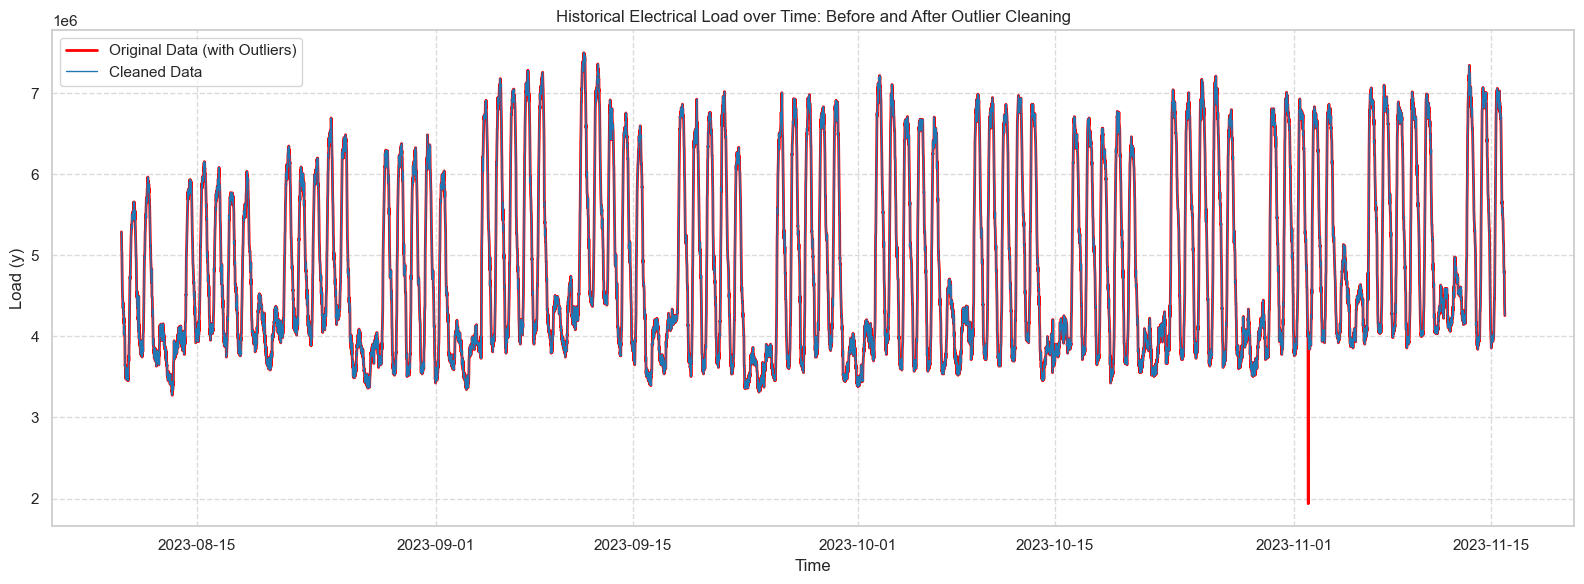


--- Splitting Data ---
Training data shape: (8608, 4)
Testing data shape: (832, 4)
Training Period: 2023-08-09 15:15:00+00:00  TO  2023-11-07 07:00:00+00:00
Testing Period:  2023-11-07 07:15:00+00:00  TO  2023-11-15 23:00:00+00:00

--- Raw Missing Values BEFORE Processing (Train) ---
shortwave_radiation    98
temperature_2m         98
windspeed_10m          98
y                       0
dtype: int64

--- Missing Values AFTER Interpolation & Cleaning (Train) ---
shortwave_radiation    0
temperature_2m         0
y                      0
dtype: int64

--- Cleaned Train DataFrame Head (5) ---
                           shortwave_radiation  temperature_2m         y  \
times                                                                      
2023-08-09 15:15:00+00:00             1.804668        0.784158  0.411667   
2023-08-09 15:30:00+00:00             1.783460        0.777953  0.358331   
2023-08-09 15:45:00+00:00             1.742721        0.762202  0.206667   
2023-08-09 16:00:00+00:0

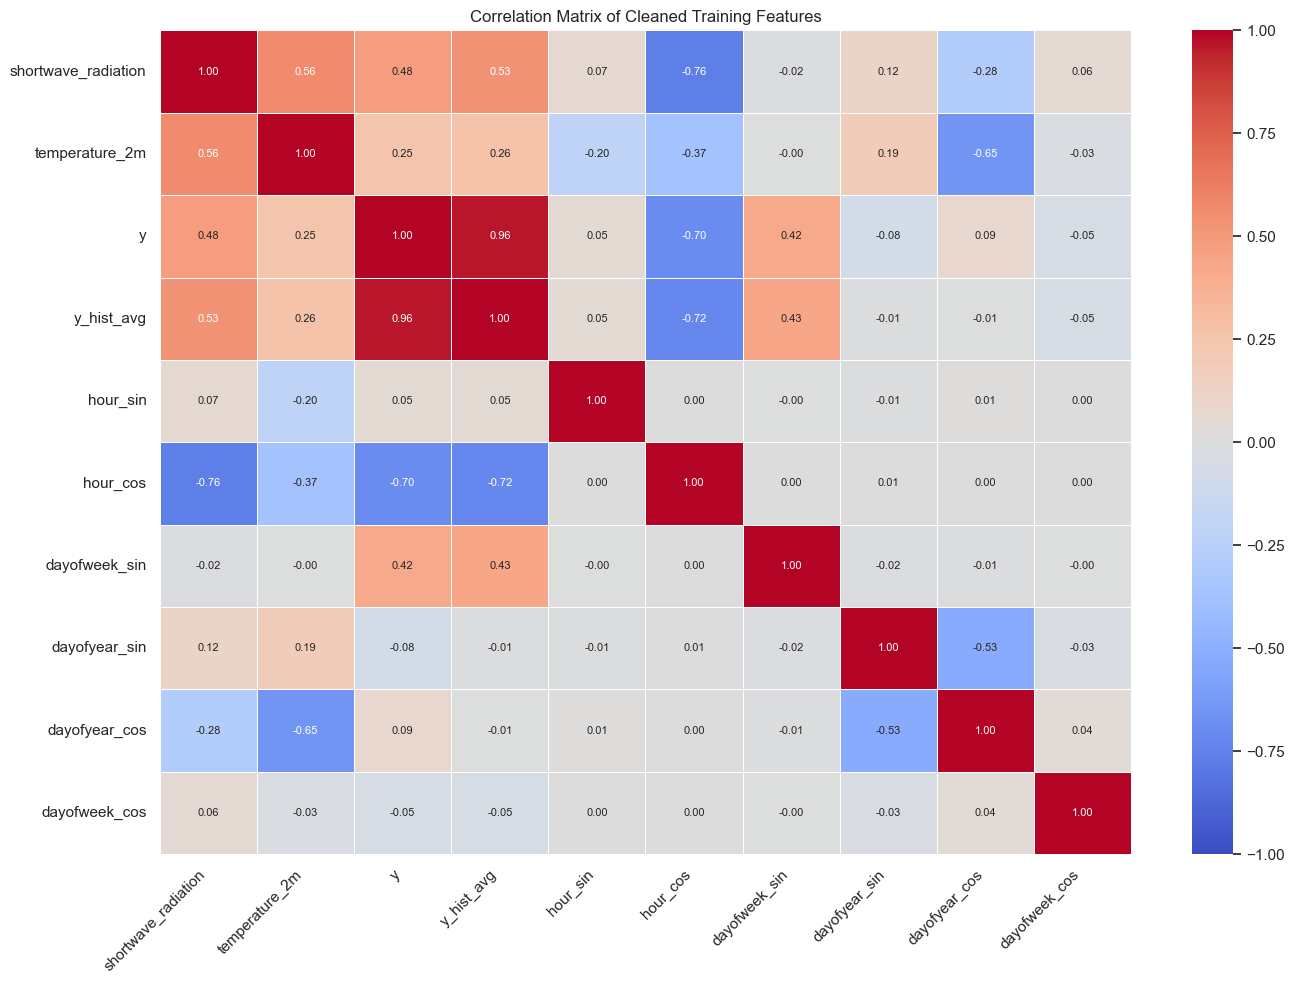

In [49]:
# ==========================================
# 3. Test Code Execution
# ==========================================
if __name__ == "__main__":
    from sklearn.model_selection import train_test_split
    import seaborn as sns
    
    # 1. Load the JSON 
    with open("request_body (1).json", "r") as f:
        payload = json.load(f)

    # 2. Parse payload 
    print("--- Parsing Data ---")
    raw_df = parse_simpl_energy_json(payload)

# 3. Handle specific load ('y') outliers visually identified
    print("\n--- Outlier Detection for Target Variable (y) ---")
    # Setting a safe threshold based on visual inspection of the normal baseload (~3.3M)
    Y_MIN_THRESHOLD = 3000000 
    
    outlier_mask = raw_df['y'] < Y_MIN_THRESHOLD
    outlier_timestamps = raw_df[outlier_mask].index
    
    print(f"Found {len(outlier_timestamps)} outlier(s) dropping below {Y_MIN_THRESHOLD}:")
    for ts in outlier_timestamps:
        print(f" - Timestamp: {ts} | Value: {raw_df.loc[ts, 'y']}")
        
    # Store original for plotting
    original_y = raw_df['y'].copy()
    
    # Replace outliers with NaN and interpolate linearly
    raw_df.loc[outlier_mask, 'y'] = np.nan
    raw_df['y'] = raw_df['y'].interpolate(method='linear')
    
    # 4. Plot Full Historical Load (Before vs After)
    print("\n--- Plotting Full Historical Load (Before vs After) ---")
    plt.figure(figsize=(16, 6))
    # Plot original in red (will show up mainly where the outlier spike is)
    plt.plot(original_y.index, original_y, color='red', linewidth=2, label='Original Data (with Outliers)')
    # Plot cleaned on top in blue
    plt.plot(raw_df.index, raw_df['y'], color='#1f77b4', linewidth=1, label='Cleaned Data')
    
    plt.title("Historical Electrical Load over Time: Before and After Outlier Cleaning")
    plt.xlabel("Time")
    plt.ylabel("Load (y)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    # 5. Chronological Split BEFORE Processing
    print("\n--- Splitting Data ---")
    train_raw, test_raw = train_test_split(raw_df, test_size=832, shuffle=False)
    print(f"Training data shape: {train_raw.shape}")
    print(f"Testing data shape: {test_raw.shape}")
    
    # Print the exact periods for Train and Test
    print(f"Training Period: {train_raw.index.min()}  TO  {train_raw.index.max()}")
    print(f"Testing Period:  {test_raw.index.min()}  TO  {test_raw.index.max()}")
    print("\n--- Raw Missing Values BEFORE Processing (Train) ---")
    print(train_raw[ ['shortwave_radiation', 'temperature_2m', 'windspeed_10m', 'y'] ].isna().sum())
    
    # 4. Process data
    processor = DataProcessor()
    
    # Fit ONLY on the training data to prevent data leakage
    processor.fit(train_raw) 
    
    # Transform cleans outliers (prints clipping stats), interpolates NaNs, scales, and adds time features
    train_clean = processor.transform(train_raw)
    test_clean = processor.transform(test_raw)
    
    print("\n--- Missing Values AFTER Interpolation & Cleaning (Train) ---")
    print(train_clean[ ['shortwave_radiation', 'temperature_2m', 'y'] ].isna().sum())
    
    print("\n--- Cleaned Train DataFrame Head (5) ---")
    print(train_clean.head(5))

    # 5. Plot Correlation Matrix
    # We compute correlation ONLY on train_clean to avoid data leakage!
    corr = train_clean.select_dtypes(include=[np.number]).corr()

    plt.figure(figsize=(14, 10))
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        linewidths=0.5,
        annot_kws={"size": 8},
    )
    plt.title("Correlation Matrix of Cleaned Training Features")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Model Training & Validation
- investigated models: RF, XGBoost, MLR, Poly, MLP
- Evaluation metrics: MAE, RMSE, nRMSE, R2
- plot: error distribution, real vs prediction (intensity & time)

In [5]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: xgboost in c:\users\vivi6\anaconda3\lib\site-packages (3.1.2)



In [50]:
import pandas as pd
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
import time

In [52]:
# Prepare 2D features (X) and target (y) for ML models (RF/XGBoost don't need 3D LSTM shapes)
X_train = train_clean.drop(columns=['y'])
y_train = train_clean['y']

X_test = test_clean.drop(columns=['y'])
y_test = test_clean['y']

# ==========================================
# Setup Time-Series Cross Validation
# ==========================================
# This creates 3 expanding windows for training/validation internally
tscv = TimeSeriesSplit(n_splits=3)

# scaling back the predictions to original units for metrics calculation
y_std_watts = processor.scaler.scale_[2]
y_mean_watts = processor.scaler.mean_[2]
max_load_watts = train_raw['y'].max()
max_load_kw = max_load_watts / 1000

In [53]:
# 4. Random Forest with Bayesian Optimization
# ==========================================
rf = RandomForestRegressor(random_state=42)

# Define the search space for RF
rf_search_space = {
    'n_estimators': Integer(50, 500),
    'max_depth': Integer(3, 15),
    'min_samples_split': Integer(2, 10),
    'min_samples_leaf': Integer(1, 5),
    'max_features': Categorical(['sqrt', None])
}

rf_bayes_search = BayesSearchCV(
    estimator=rf,
    search_spaces=rf_search_space,
    n_iter=30, # Number of hyperparameter combinations to try (increase if you have time)
    cv=tscv,   # Use the TimeSeriesSplit
    scoring='neg_mean_squared_error',
    n_jobs=-1, # Use all CPU cores
    random_state=42,
    verbose=1
)

# Run the optimization
rf_start_total = time.time()
rf_bayes_search.fit(X_train, y_train)
rf_end_total = time.time()
print(f"Total RF Optimization Time: {rf_end_total - rf_start_total:.2f} seconds")
print(f"Best RF Parameters: {rf_bayes_search.best_params_}")
print(f"Best RF Score (MSE): {-rf_bayes_search.best_score_:.4f}")

Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fi

In [54]:
# Evaluate on the locked-away test set
rf_best = rf_bayes_search.best_estimator_
rf_preds = rf_best.predict(X_test)

rf_mae_scaled = mean_absolute_error(y_test, rf_preds)
rf_rmse_scaled = root_mean_squared_error(y_test, rf_preds)

rf_mae_kw = (rf_mae_scaled * y_std_watts) / 1000
rf_rmse_kw = (rf_rmse_scaled * y_std_watts) / 1000
rf_nrmse = rf_rmse_kw / max_load_kw

print(f"RF Test MAE: {rf_mae_kw:.4f} kW")
print(f"RF Test RMSE: {rf_rmse_kw:.4f} kW")
print(f"RF Test NRMSE: {rf_nrmse:.4f}")
print(f"RF Test R²: {r2_score(y_test, rf_preds):.4f}")


RF Test MAE: 191.0256 kW
RF Test RMSE: 257.0915 kW
RF Test NRMSE: 0.0343
RF Test R²: 0.9486


In [55]:
# ==========================================
# 5. XGBoost with Bayesian Optimization
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, tree_method= 'exact')

# Define the search space for XGBoost
xgb_search_space = {
    'n_estimators': Integer(50, 800),
    'max_depth': Integer(3, 10),
    'learning_rate': Real(0.01, 0.3, prior='log-uniform'),
    'subsample': Real(0.5, 1.0),
    'colsample_bytree': Real(0.5, 1.0),
    'min_child_weight': Integer(1, 20) 
}

xgb_bayes_search = BayesSearchCV(
    estimator=xgb_model,
    search_spaces=xgb_search_space,
    n_iter=30,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Run the optimization
xgb_start_total = time.time()
xgb_bayes_search.fit(X_train, y_train)
xgb_end_total = time.time()
print(f"Total XGBoost Optimization Time: {xgb_end_total - xgb_start_total:.2f} seconds")
print(f"Best XGBoost Parameters: {xgb_bayes_search.best_params_}")
print(f"Best XGBoost Score (MSE): {-xgb_bayes_search.best_score_:.4f}")

Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fi

In [56]:
# Evaluate on the locked-away test set
xgb_best = xgb_bayes_search.best_estimator_
xgb_preds = xgb_best.predict(X_test)
xgb_mae_scaled = mean_absolute_error(y_test, xgb_preds)
xgb_rmse_scaled = root_mean_squared_error(y_test, xgb_preds)

xgb_mae_kw = (xgb_mae_scaled * y_std_watts) / 1000
xgb_rmse_kw = (xgb_rmse_scaled * y_std_watts) / 1000
xgb_nrmse = xgb_rmse_kw / max_load_kw

print(f"XGB Test MAE: {xgb_mae_kw:.4f} kW")
print(f"XGB Test RMSE: {xgb_rmse_kw:.4f} kW")
print(f"XGB Test NRMSE: {xgb_nrmse:.4f}")
print(f"XGB Test R²: {r2_score(y_test, xgb_preds):.4f}")


XGB Test MAE: 191.5969 kW
XGB Test RMSE: 242.8973 kW
XGB Test NRMSE: 0.0324
XGB Test R²: 0.9541


In [57]:
start_ploy_train = time.time()
# Creat polynomial feature
poly = PolynomialFeatures(degree=2)

x_poly_train = poly.fit_transform(X_train)
# Train the model on poly feature
lin_poly= LinearRegression()
lin_poly.fit(x_poly_train, y_train)

# Stop the timer immediately after fitting is done
end_poly_train = time.time()
poly_training_time = end_poly_train - start_ploy_train

print(f"Poly Training Time (Degree 2): {poly_training_time:.6f} seconds")
print("Intercept:", lin_poly.intercept_)
print("Coefficients:", lin_poly.coef_)
print("Feature Names:", poly.get_feature_names_out(X_train.columns))

x_poly_test = poly.transform(X_test)
poly_preds = lin_poly.predict(x_poly_test)

poly_mae_scaled = mean_absolute_error(y_test, poly_preds)
poly_rmse_scaled = root_mean_squared_error(y_test, poly_preds)

poly_mae_kw = (poly_mae_scaled * y_std_watts) / 1000
poly_rmse_kw = (poly_rmse_scaled * y_std_watts) / 1000
poly_nrmse = poly_rmse_kw / max_load_kw

print(f"Poly Test MAE: {poly_mae_kw:.4f} kW")
print(f"Poly Test RMSE: {poly_rmse_kw:.4f} kW")
print(f"Poly Test NRMSE: {poly_nrmse:.4f}")
print(f"Poly Test R²: {r2_score(y_test, poly_preds):.4f}")

Poly Training Time (Degree 2): 0.045997 seconds
Intercept: -1440229461.642028
Coefficients: [-5.38405367e-15  7.62719648e-02 -8.90340016e-01 -6.62354629e-02
 -7.24485734e-01 -5.10948676e-01 -1.43970203e-03 -3.38117993e+00
 -7.82355231e-02 -1.08154778e-01 -3.18574309e-02  2.94374615e-02
  1.27211941e-02 -1.73295555e-02 -8.21187481e-02 -3.21492456e-02
  1.66203147e-01 -1.71559256e-02  1.28335573e-02  3.80311582e-02
  5.48016201e-02 -2.01882998e-02  9.21049911e-02 -4.10250115e-02
 -1.09306614e+00 -3.80163281e-01 -1.56275748e-02  2.90945709e-02
  2.63262839e-02  6.83132828e-02 -1.33092810e-02 -1.11495883e+00
  1.08331246e-01  5.77818867e-03 -2.33588466e+07 -3.79185956e-02
 -2.73253513e-02 -8.28103700e-01 -2.66818412e-01 -4.23039906e-03
 -2.33588466e+07 -9.20497462e-02 -5.50797656e-01 -2.34885176e-01
  3.16176740e-02  3.11564826e+08 -1.90596895e-02 -1.13919554e-01
 -6.76719404e-03  1.15202348e+09 -2.12285405e-01 -8.35224522e-02
  1.15202348e+09 -2.19886276e-02  3.11564826e+08]
Feature Names

In [58]:
start_mlr_train = time.time()
mlr = PolynomialFeatures(degree=1)
x_mlr_train = mlr.fit_transform(X_train)

lin_mlr = LinearRegression()
lin_mlr.fit(x_mlr_train, y_train)

end_mlr_train = time.time()
mlr_training_time = end_mlr_train - start_mlr_train
print(f"MLR Training Time (Degree 1): {mlr_training_time:.6f} seconds")
print("Intercept:", lin_mlr.intercept_)
print("Coefficients:", lin_mlr.coef_)
print("Feature Names:", mlr.get_feature_names_out(X_train.columns))

x_mlr_test = mlr.transform(X_test)
mlr_preds = lin_mlr.predict(x_mlr_test)

mlr_mae_scaled = mean_absolute_error(y_test, mlr_preds)
mlr_rmse_scaled = root_mean_squared_error(y_test, mlr_preds)

mlr_mae_kw = (mlr_mae_scaled * y_std_watts) / 1000
mlr_rmse_kw = (mlr_rmse_scaled * y_std_watts) / 1000
mlr_nrmse = mlr_rmse_kw / max_load_kw

print(f"MLR Test MAE: {mlr_mae_kw:.4f} kW")
print(f"MLR Test RMSE: {mlr_rmse_kw:.4f} kW")
print(f"MLR Test NRMSE: {mlr_nrmse:.4f}")
print(f"MLR Test R²: {r2_score(y_test, mlr_preds):.4f}")


MLR Training Time (Degree 1): 0.010736 seconds
Intercept: 0.08484225565743002
Coefficients: [ 0.         -0.09163994  0.16559785  0.9545976   0.05427042 -0.01265714
  0.00652632  0.03646608  0.42757754  0.00240671]
Feature Names: ['1' 'shortwave_radiation' 'temperature_2m' 'y_hist_avg' 'hour_sin'
 'hour_cos' 'dayofweek_sin' 'dayofyear_sin' 'dayofyear_cos'
 'dayofweek_cos']
MLR Test MAE: 356.1686 kW
MLR Test RMSE: 427.4185 kW
MLR Test NRMSE: 0.0570
MLR Test R²: 0.8579


In [59]:
mlp = MLPRegressor(activation='relu', solver='adam', max_iter=5000, random_state=42, early_stopping = True)
layer_shapes=[
# 2 Layers
(8, 16), (16, 8), (16, 16),
# 3 Layers
(8, 8, 8), (32, 16, 8), (16, 16, 8),
(16, 16, 16), (32, 32, 16)]

mlp_para = {'hidden_layer_sizes': layer_shapes,
            'learning_rate_init': [0.001, 0.0001],
            'alpha': [0.001, 0.01, 1]
           }
grid_search_mlp = GridSearchCV(estimator=mlp, param_grid=mlp_para, 
                           cv=tscv, 
                           scoring='neg_mean_squared_error',
                           n_jobs=-1, verbose=1)

# The timer here is just for the TOTAL search
mlp_start_total = time.time()
grid_search_mlp.fit(X_train, y_train)
mlp_end_total = time.time()
print(f"Total MLP Optimization Time: {mlp_end_total - mlp_start_total:.2f} seconds")
print(f"Best MLP Parameters: {grid_search_mlp.best_params_}")
print(f"Best MLP Score (MSE): {-grid_search_mlp.best_score_:.4f}")


Fitting 3 folds for each of 48 candidates, totalling 144 fits
Total MLP Optimization Time: 34.37 seconds
Best MLP Parameters: {'alpha': 1, 'hidden_layer_sizes': (32, 32, 16), 'learning_rate_init': 0.001}
Best MLP Score (MSE): 0.0792


In [60]:
# Evaluate on the locked-away test set
mlp_best = grid_search_mlp.best_estimator_
mlp_preds = mlp_best.predict(X_test)
mlp_mae_scaled = mean_absolute_error(y_test, mlp_preds)
mlp_rmse_scaled = root_mean_squared_error(y_test, mlp_preds)

mlp_mae_kw = (mlp_mae_scaled * y_std_watts) / 1000
mlp_rmse_kw = (mlp_rmse_scaled * y_std_watts) / 1000
mlp_nrmse = mlp_rmse_kw / max_load_kw

print(f"MLP Test MAE: {mlp_mae_kw:.4f} kW")
print(f"MLP Test RMSE: {mlp_rmse_kw:.4f} kW")
print(f"MLP Test NRMSE: {mlp_nrmse:.4f}")
print(f"MLP Test R²: {r2_score(y_test, mlp_preds):.4f}")

MLP Test MAE: 205.6281 kW
MLP Test RMSE: 277.1985 kW
MLP Test NRMSE: 0.0370
MLP Test R²: 0.9402


NameError: name 'self' is not defined